# EEGConformer — Acoustic Model Training

**Workflow:**
1. Install dependencies & mount Drive
2. Set your paths in the **Configuration** cell
3. Run all cells top-to-bottom
4. Phase 1 trains from scratch (OneCycleLR, 50 epochs)
5. Phase 2 fine-tunes from the best Phase 1 checkpoint (ReduceLROnPlateau, 50 epochs)

Checkpoints are saved automatically to your Drive whenever validation loss improves.

The preprocessed data index files (`val_index_merged.pkl`) are not included in this repository due to file size (~2 GB).

Download them from [Google Drive]
https://drive.google.com/file/d/1jumosK6v5lngly8MzqbpkDEjyaSdxMRE/view?usp=drive_link and replace the path in code.

# Dependency

In [1]:
!pip install -q einops evaluate jiwer h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 46.7 MB/s eta 0:00:00


In [2]:
import math
import os
import gc
import glob
import random
import shutil

import h5py
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor
from torch.utils.data import Sampler, Dataset as TorchDataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from einops import rearrange
from einops.layers.torch import Rearrange
from tqdm.auto import tqdm
from google.colab import drive
import matplotlib.pyplot as plt
import pickle

print('Imports OK')
print('PyTorch:', torch.__version__)
print('CUDA available:', torch.cuda.is_available())

Imports OK
PyTorch: 2.10.0+cu128
CUDA available: True


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
# ================================================================
#  CONFIGURATION — edit these paths before running
# ================================================================

# Where to save checkpoints
SAVE_DIR        = '/content/drive/MyDrive/SpeechModels'

# ── Model hyperparameters ─────────────────────────────────────
CONFIG = {
    'emb_size':        128,
    'num_electrodes':  512,
    'temporal_kernel': (1, 10),
    'pool_kernel':     (1, 15),
    'pool_stride':     (1, 8),
    'depth':           6,
    'num_heads':       8,
    'drop_p':          0.3,
    'num_phonemes':    40,
    'ffn_hidden':      256,
}

# ── Training hyperparameters ──────────────────────────────────
BATCH_SIZE     = 28
MAX_TIME_STEPS = 1500
PHASE1_EPOCHS  = 50
PHASE1_LR      = 1e-3
PHASE2_EPOCHS  = 100
PHASE2_LR      = 1e-4

os.makedirs(SAVE_DIR, exist_ok=True)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Save dir: {SAVE_DIR}')

LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B', 'CH', 'D', 'DH',
    'EH', 'ER', 'EY', 'F', 'G', 'HH', 'IH', 'IY', 'JH', 'K', 'L', 'M',
    'N', 'NG', 'OW', 'OY', 'P', 'R', 'S', 'SH', 'T', 'TH', 'UH', 'UW',
    'V', 'W', 'Y', 'Z', 'ZH', '|'
]


Device: cuda
Save dir: /content/drive/MyDrive/SpeechModels


# Data preparation

In [5]:
# ================================================================
# Dataset, Sampler, Collate
# ================================================================

class SpeechDataset(TorchDataset):
    def __init__(self, data_dict, max_time_steps=1500):
        self.data = data_dict
        self.length = len(data_dict['neural_features'])
        self.max_time_steps = max_time_steps

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        n_time_steps      = int(self.data['n_time_steps'][idx])
        seq_len           = int(self.data['seq_len'][idx])
        effective_n_steps = min(n_time_steps, self.max_time_steps)

        neural   = self.data['neural_features'][idx][:effective_n_steps]
        phonemes = self.data['seq_class_ids'][idx][:seq_len]

        neural_tensor  = torch.from_numpy(neural).float().transpose(0, 1).unsqueeze(0)
        phoneme_tensor = torch.from_numpy(phonemes.astype(np.int64))
        return neural_tensor, phoneme_tensor, seq_len, effective_n_steps


class BucketBatchSampler(Sampler):
    """Sort by length then shuffle batch order — minimises within-batch padding."""
    def __init__(self, dataset, batch_size, drop_last=False):
        self.dataset    = dataset
        self.batch_size = batch_size
        self.drop_last  = drop_last
        self.sorted_indices = sorted(
            range(len(dataset)),
            key=lambda i: dataset.data['n_time_steps'][i]
        )

    def __iter__(self):
        batches = [self.sorted_indices[i:i + self.batch_size]
                   for i in range(0, len(self.sorted_indices), self.batch_size)]
        random.shuffle(batches)
        for batch in batches:
            if not self.drop_last or len(batch) == self.batch_size:
                yield batch

    def __len__(self):
        if self.drop_last:
            return len(self.dataset) // self.batch_size
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size


def collate_fn(batch):
    neurals, phonemes_list, seq_lens, time_steps = zip(*batch)
    neurals_reshaped = [n.squeeze(0).transpose(0, 1) for n in neurals]
    neural_batch = (pad_sequence(neurals_reshaped, batch_first=True)
                    .transpose(1, 2).unsqueeze(1))
    phoneme_batch  = pad_sequence(phonemes_list, batch_first=True, padding_value=0)
    seq_len_batch  = torch.tensor(seq_lens,   dtype=torch.long)
    time_step_batch = torch.tensor(time_steps, dtype=torch.long)
    return neural_batch, phoneme_batch, seq_len_batch, time_step_batch

# EEG Conformer

In [6]:
# ================================================================
# Model: EEGConformer
# ================================================================

class PatchEmbedding(nn.Module):
    def __init__(self, emb_size=128, num_electrodes=512,
                 temporal_kernel=(1, 10), pool_kernel=(1, 15), pool_stride=(1, 8)):
        super().__init__()
        pad_w = temporal_kernel[1] // 2
        self.temporal_conv = nn.Conv2d(1, 128, kernel_size=temporal_kernel,
                                       stride=(1, 1), padding=(0, pad_w))
        self.spatial_conv  = nn.Conv2d(128, 128, kernel_size=(num_electrodes, 1),
                                       stride=(1, 1), groups=128)
        self.bn      = nn.BatchNorm2d(128)
        self.act     = nn.ELU()
        self.pool    = nn.AvgPool2d(kernel_size=pool_kernel, stride=pool_stride)
        self.dropout = nn.Dropout(0.5)
        self.projection = nn.Sequential(
            nn.Conv2d(128, emb_size, kernel_size=(1, 1)),
            Rearrange('b e (h) (w) -> b (h w) e'),
        )

    def forward(self, x: Tensor) -> Tensor:
        x = self.temporal_conv(x)
        x = self.spatial_conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.pool(x)
        x = self.dropout(x)
        return self.projection(x)


class PositionalEncoding(nn.Module):
    def __init__(self, emb_size: int, dropout: float = 0.1, max_len: int = 5000):
        super().__init__()
        self.dropout  = nn.Dropout(p=dropout)
        position      = torch.arange(max_len).unsqueeze(1)
        div_term      = torch.exp(torch.arange(0, emb_size, 2) * (-math.log(10000.0) / emb_size))
        pe            = torch.zeros(1, max_len, emb_size)
        pe[0, :, 0::2] = torch.sin(position * div_term)
        pe[0, :, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: Tensor) -> Tensor:
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class MultiHeadAttention(nn.Module):
    def __init__(self, emb_size: int, num_heads: int, dropout: float):
        super().__init__()
        assert emb_size % num_heads == 0
        self.num_heads = num_heads
        self.dropout_p = dropout
        self.queries    = nn.Linear(emb_size, emb_size)
        self.keys       = nn.Linear(emb_size, emb_size)
        self.values     = nn.Linear(emb_size, emb_size)
        self.projection = nn.Linear(emb_size, emb_size)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        Q = rearrange(self.queries(x), 'b n (h d) -> b h n d', h=self.num_heads)
        K = rearrange(self.keys(x),    'b n (h d) -> b h n d', h=self.num_heads)
        V = rearrange(self.values(x),  'b n (h d) -> b h n d', h=self.num_heads)
        out = F.scaled_dot_product_attention(
            Q, K, V, attn_mask=mask,
            dropout_p=self.dropout_p if self.training else 0.0, is_causal=False)
        return self.projection(rearrange(out, 'b h n d -> b n (h d)'))


class FeedForwardBlock(nn.Sequential):
    def __init__(self, emb_size: int, expansion: int = 4, drop_p: float = 0.3):
        super().__init__(
            nn.Linear(emb_size, expansion * emb_size),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(expansion * emb_size, emb_size),
        )


class TransformerEncoderBlock(nn.Module):
    def __init__(self, emb_size, num_heads=8, drop_p=0.3,
                 forward_expansion=4, forward_drop_p=0.3):
        super().__init__()
        self.norm1 = nn.LayerNorm(emb_size)
        self.attn  = MultiHeadAttention(emb_size, num_heads, drop_p)
        self.drop1 = nn.Dropout(drop_p)
        self.norm2 = nn.LayerNorm(emb_size)
        self.ff    = FeedForwardBlock(emb_size, forward_expansion, forward_drop_p)
        self.drop2 = nn.Dropout(drop_p)

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        res = x; x = self.norm1(x); x = self.attn(x, mask=mask); x = res + self.drop1(x)
        res = x; x = self.norm2(x); x = self.ff(x);               x = res + self.drop2(x)
        return x


class TransformerEncoder(nn.Module):
    def __init__(self, depth: int, emb_size: int):
        super().__init__()
        self.layers = nn.ModuleList([TransformerEncoderBlock(emb_size) for _ in range(depth)])

    def forward(self, x: Tensor, mask: Tensor = None) -> Tensor:
        for layer in self.layers:
            x = layer(x, mask=mask)
        return x


class NeuralEncoder(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.patch_embedding = PatchEmbedding(
            emb_size=config['emb_size'], num_electrodes=config['num_electrodes'],
            temporal_kernel=config['temporal_kernel'],
            pool_kernel=config['pool_kernel'], pool_stride=config['pool_stride'])
        self.pos_encoder = PositionalEncoding(config['emb_size'], dropout=config['drop_p'])
        self.transformer = TransformerEncoder(depth=config['depth'], emb_size=config['emb_size'])
        self.norm = nn.LayerNorm(config['emb_size'])

    def forward(self, x: Tensor, input_lengths: Tensor = None) -> Tensor:
        x = self.patch_embedding(x)
        x = self.pos_encoder(x)
        mask = None
        if input_lengths is not None:
            B, T, _ = x.shape
            seq_range = torch.arange(T, device=x.device).expand(B, T)
            bool_mask = seq_range < input_lengths.unsqueeze(1)
            mask = bool_mask.unsqueeze(1).unsqueeze(2)
        x = self.transformer(x, mask=mask)
        return self.norm(x)


class PhonemeHead(nn.Module):
    def __init__(self, emb_size, num_phonemes, ffn_hidden=256, drop_p=0.3):
        super().__init__()
        self.ffn = nn.Sequential(
            nn.Linear(emb_size, ffn_hidden),
            nn.GELU(),
            nn.Dropout(drop_p),
            nn.Linear(ffn_hidden, num_phonemes + 1),  # +1 for CTC blank
        )

    def forward(self, x: Tensor) -> Tensor:
        return self.ffn(x)


class NeuralSpeechModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config  = config
        self.encoder = NeuralEncoder(config)
        self.head    = PhonemeHead(
            emb_size=config['emb_size'], num_phonemes=config['num_phonemes'],
            ffn_hidden=config['ffn_hidden'], drop_p=config['drop_p'])

    def forward(self, x: Tensor, input_lengths: Tensor = None):
        x = self.encoder(x, input_lengths)
        x = self.head(x)
        x = F.log_softmax(x, dim=-1)
        num_tokens = x.shape[1]
        x = x.permute(1, 0, 2)  # (T, B, C) for CTCLoss
        return x, num_tokens


print('Model classes defined.')

Model classes defined.


# Training

In [21]:
# ================================================================
# Training & validation functions
# ================================================================

def compute_token_lengths(input_time_steps, pool_kernel, pool_stride):
    return ((input_time_steps - pool_kernel) // pool_stride + 1).long()


def train_one_epoch(model, optimizer, scheduler, train_loader, device, scaler):
    model.train()
    total_loss, num_batches = 0.0, 0
    k_w = model.config['pool_kernel'][1]
    s_w = model.config['pool_stride'][1]

    for neural_batch, phoneme_batch, seq_len_batch, input_time_steps in tqdm(train_loader, leave=False):
        try:
            neural_batch  = neural_batch.to(device)
            phoneme_batch = phoneme_batch.to(device)
            seq_len_batch = seq_len_batch.to(device)
            input_lengths = compute_token_lengths(
                input_time_steps, pool_kernel=k_w, pool_stride=s_w).to(device)

            optimizer.zero_grad()
            with torch.autocast(device_type=device.type, dtype=torch.float16):
                log_probs, _ = model(neural_batch, input_lengths)

            loss = F.ctc_loss(
                log_probs, phoneme_batch, input_lengths, seq_len_batch,
                blank=0, reduction='mean', zero_infinity=True)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            if scheduler is not None and not isinstance(
                    scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step()

            total_loss  += loss.item()
            num_batches += 1

        except torch.cuda.OutOfMemoryError:
            print('\n[OOM] Skipping batch...')
            torch.cuda.empty_cache()
            optimizer.zero_grad()

    return total_loss / num_batches if num_batches > 0 else float('inf')


def validate(model, val_loader, device):
    model.eval()
    total_loss, num_batches = 0.0, 0
    k_w = model.config['pool_kernel'][1]
    s_w = model.config['pool_stride'][1]

    with torch.no_grad():
        for neural_batch, phoneme_batch, seq_len_batch, input_time_steps in val_loader:
            neural_batch  = neural_batch.to(device)
            phoneme_batch = phoneme_batch.to(device)
            seq_len_batch = seq_len_batch.to(device)
            input_lengths = compute_token_lengths(
                input_time_steps, pool_kernel=k_w, pool_stride=s_w).to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                log_probs, _ = model(neural_batch, input_lengths)

            loss = F.ctc_loss(
                log_probs, phoneme_batch, input_lengths, seq_len_batch,
                blank=0, reduction='mean', zero_infinity=True)
            total_loss  += loss.item()
            num_batches += 1

    return total_loss / num_batches


print('Training functions defined.')

Training functions defined.


# Import data

In [19]:
# ================================================================
# Load data
# ================================================================

shutil.copy('/content/drive/MyDrive/train_index_merged.pkl', '/content/train_index_merged.pkl')
shutil.copy('/content/drive/MyDrive/val_index_merged.pkl', '/content/val_index_merged.pkl')

with open('/content/train_index_merged.pkl', 'rb') as f:
    train_index = pickle.load(f)
with open('/content/val_index_merged.pkl', 'rb') as f:
    val_index = pickle.load(f)

# The Dataset and DataLoader logic remains exactly the same
train_dataset = SpeechDataset(train_index, max_time_steps=MAX_TIME_STEPS)
val_dataset   = SpeechDataset(val_index,   max_time_steps=MAX_TIME_STEPS)

train_sampler = BucketBatchSampler(train_dataset, batch_size=BATCH_SIZE)
val_sampler   = BucketBatchSampler(val_dataset,   batch_size=BATCH_SIZE)

train_loader = DataLoader(train_dataset, batch_sampler=train_sampler,
                          collate_fn=collate_fn, num_workers=2,
                          pin_memory=True, prefetch_factor=2)
val_loader   = DataLoader(val_dataset,   batch_sampler=val_sampler,
                          collate_fn=collate_fn, num_workers=2,
                          pin_memory=True, prefetch_factor=2)

print(f'Train trials : {len(train_dataset)}')
print(f'Val trials   : {len(val_dataset)}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')

Train trials : 7903
Val trials   : 1378
Train batches: 283
Val batches  : 50


# Phase Ⅰ

In [22]:
# ================================================================
# Phase 1 — Train from scratch (OneCycleLR)
# ================================================================
model = NeuralSpeechModel(CONFIG).to(device)
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

optimizer = torch.optim.AdamW(model.parameters(), lr=PHASE1_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=PHASE1_LR,
    steps_per_epoch=len(train_loader), epochs=PHASE1_EPOCHS)
scaler = torch.amp.GradScaler('cuda')

best_val_loss = float('inf')
best_ckpt_path = None

print(f'\n--- Phase 1 Training ({PHASE1_EPOCHS} epochs) ---')
for epoch in range(1, PHASE1_EPOCHS + 1):
    train_loss = train_one_epoch(model, optimizer, scheduler, train_loader, device, scaler)
    val_loss   = validate(model, val_loader, device)
    print(f'Epoch {epoch:3d}/{PHASE1_EPOCHS} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_ckpt_path = os.path.join(SAVE_DIR, f'phase1_epoch{epoch:03d}_loss{val_loss:.4f}.pth')
        torch.save(model.state_dict(), best_ckpt_path)
        print(f'  → Saved: {best_ckpt_path}')

print(f'\nPhase 1 complete. Best val loss: {best_val_loss:.4f}')
print(f'Best checkpoint: {best_ckpt_path}')

Trainable params: 1,317,289

--- Phase 1 Training (50 epochs) ---


  0%|          | 0/283 [00:00<?, ?it/s]

/tmp/ipykernel_1324/2168749068.py:38: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


KeyboardInterrupt: 

# Phase Ⅱ

In [ ]:
# ================================================================
# Phase 2 — Fine-tune from best Phase 1 checkpoint (ReduceLROnPlateau)
#
# If you're resuming after a restart, set best_ckpt_path manually:
# best_ckpt_path = '/content/drive/MyDrive/SpeechModels/phase1_epoch050_loss0.xxxx.pth'
# ================================================================

# Phase 2 uses slightly lower dropout for faster convergence
phase2_config = {**CONFIG, 'drop_p': 0.2}

model = NeuralSpeechModel(phase2_config).to(device)
model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
print(f'Loaded Phase 1 checkpoint: {best_ckpt_path}')

optimizer = torch.optim.AdamW(model.parameters(), lr=PHASE2_LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, verbose=True)
scaler = torch.amp.GradScaler('cuda')

best_val_loss_p2 = float('inf')
best_ckpt_path_p2 = None

print(f'\n--- Phase 2 Fine-tuning ({PHASE2_EPOCHS} epochs) ---')
for epoch in range(1, PHASE2_EPOCHS + 1):
    train_loss = train_one_epoch(model, optimizer, None, train_loader, device, scaler)
    val_loss   = validate(model, val_loader, device)
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    print(f'Epoch {epoch:3d}/{PHASE2_EPOCHS} | LR: {current_lr:.2e} | Train: {train_loss:.4f} | Val: {val_loss:.4f}')

    if val_loss < best_val_loss_p2:
        best_val_loss_p2 = val_loss
        best_ckpt_path_p2 = os.path.join(SAVE_DIR, f'phase2_epoch{epoch:03d}_loss{val_loss:.4f}.pth')
        torch.save(model.state_dict(), best_ckpt_path_p2)
        print(f'  → Saved: {best_ckpt_path_p2}')

print(f'\nPhase 2 complete. Best val loss: {best_val_loss_p2:.4f}')
print(f'Best checkpoint: {best_ckpt_path_p2}')

In [ ]:
# ================================================================
# Quick sanity check — greedy CTC decode on a few val samples
# ================================================================
LOGIT_TO_PHONEME = [
    'BLANK', 'AA', 'AE', 'AH', 'AO', 'AW', 'AY', 'B',  'CH', 'D',  'DH',
    'EH', 'ER', 'EY', 'F',  'G',  'HH', 'IH', 'IY', 'JH', 'K',
    'L',  'M',  'N',  'NG', 'OW', 'OY', 'P',  'R',  'S',  'SH',
    'T',  'TH', 'UH', 'UW', 'V',  'W',  'Y',  'Z',  'ZH', '|',
]

def greedy_decode(log_probs, blank_id=0):
    tokens = log_probs.argmax(dim=-1).cpu().numpy()  # (T, B)
    decoded = []
    for b in range(tokens.shape[1]):
        seq, prev = [], -1
        for t in range(tokens.shape[0]):
            tok = int(tokens[t, b])
            if tok != blank_id and tok != prev:
                seq.append(tok)
            prev = tok
        decoded.append(seq)
    return decoded

def per(ref, hyp):
    n, m = len(ref), len(hyp)
    dp = list(range(m + 1))
    for i in range(1, n + 1):
        prev = dp[:]; dp[0] = i
        for j in range(1, m + 1):
            dp[j] = min(prev[j]+1, dp[j-1]+1, prev[j-1]+(0 if ref[i-1]==hyp[j-1] else 1))
    return dp[m] / max(n, 1)

model.eval()
k_w = model.config['pool_kernel'][1]
s_w = model.config['pool_stride'][1]
all_pers = []

with torch.no_grad():
    for neural_batch, phoneme_batch, seq_len_batch, input_time_steps in val_loader:
        neural_batch  = neural_batch.to(device)
        input_lengths = compute_token_lengths(input_time_steps, k_w, s_w).to(device)
        with torch.autocast(device_type=device.type, dtype=torch.float16):
            log_probs, _ = model(neural_batch, input_lengths)
        hyps = greedy_decode(log_probs)
        for i, hyp in enumerate(hyps):
            slen = int(seq_len_batch[i].item())
            ref  = phoneme_batch[i, :slen].tolist()
            all_pers.append(per(ref, hyp))

print(f'Validation PER: {100 * sum(all_pers) / len(all_pers):.2f}%')
print(f'Samples evaluated: {len(all_pers)}')

# Evaluation

Loaded: /content/drive/MyDrive/SpeechModels/phase6_model_epoch_39_loss_0.9722.pth


Evaluating:   0%|          | 0/50 [00:00<?, ?it/s]


Reference                                               | Hypothesis                                              | PER
------------------------------------------------------------------------------------------------------------------------
DH AE T | W UH D |                                      | DH AE T | W AH N |                                      | 20.0%
AA R | Y UW | AH |                                      | AA R | Y UW | AH |                                      | 22.7%
HH IY | T UH K | K                                      | Y IY | D K | K EH                                       | 23.5%
DH AE T | IH Z | S                                      | DH AE T | IH Z | R                                      | 25.0%
IH T | IH Z | L AY                                      | IH T | IH Z | L AY                                      | 20.0%
W EH N | Y UW | S                                       | W EH N | Y UW | S                                       | 15.4%
W ER S | IH Z | DH        

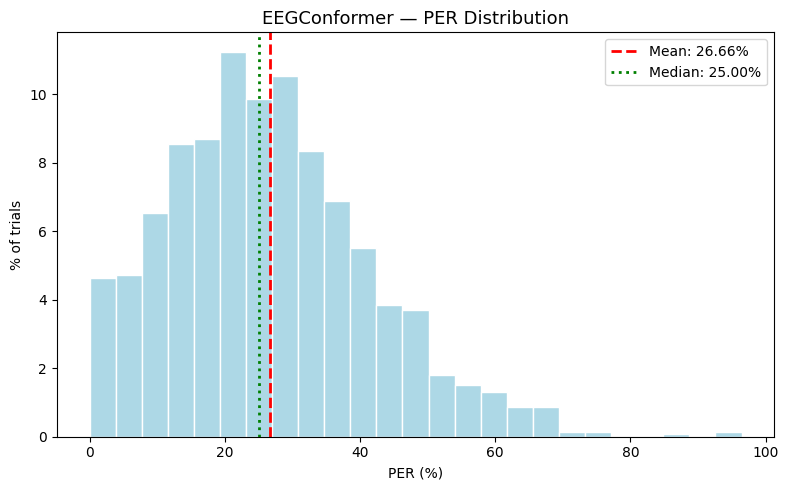

In [17]:
# ── 1. Load checkpoint ────────────────────────────────────────────
EVAL_CKPT = '/content/drive/MyDrive/SpeechModels/phase6_model_epoch_39_loss_0.9722.pth'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

eval_config = {
    'emb_size':        128,
    'num_electrodes':  512,
    'temporal_kernel': (1, 10),
    'pool_kernel':     (1, 15),
    'pool_stride':     (1, 8),
    'depth':           6,
    'num_heads':       8,
    'drop_p':          0.2,
    'num_phonemes':    40,
    'ffn_hidden':      256,
}

model_eval = NeuralSpeechModel(eval_config).to(device)
model_eval.load_state_dict(torch.load(EVAL_CKPT, map_location=device))
model_eval.eval()
print(f'Loaded: {EVAL_CKPT}')

def compute_token_lengths(input_time_steps, pool_kernel, pool_stride):
    return ((input_time_steps - pool_kernel) // pool_stride + 1).long()

# ── 2. Greedy decode ──────────────────────────────────────────────
def greedy_decode(log_probs, blank_id=0):
    """(T, B, C) → list of decoded int sequences."""
    tokens = log_probs.argmax(dim=-1).cpu().numpy()
    decoded = []
    for b in range(tokens.shape[1]):
        seq, prev = [], -1
        for t in range(tokens.shape[0]):
            tok = int(tokens[t, b])
            if tok != blank_id and tok != prev:
                seq.append(tok)
            prev = tok
        decoded.append(seq)
    return decoded

# ── 3. PER calculation ────────────────────────────────────────────
def levenshtein(a, b):
    n, m = len(a), len(b)
    dp = np.arange(m + 1)
    for i in range(1, n + 1):
        prev = dp.copy(); dp[0] = i
        for j in range(1, m + 1):
            dp[j] = min(prev[j]+1, dp[j-1]+1, prev[j-1]+(0 if a[i-1]==b[j-1] else 1))
    return dp[m]

# ── 4. Full evaluation loop ───────────────────────────────────────
k_w = eval_config['pool_kernel'][1]
s_w = eval_config['pool_stride'][1]

all_refs, all_hyps, all_pers = [], [], []

with torch.no_grad():
    for batch_feat, batch_ids, batch_lens, input_time_steps in tqdm(val_loader, desc='Evaluating'):
        batch_feat = batch_feat.to(device)
        input_lengths = compute_token_lengths(input_time_steps, k_w, s_w).to(device)

        with torch.autocast(device_type=device.type, dtype=torch.float16):
            log_probs, _ = model_eval(batch_feat, input_lengths)

        hyps = greedy_decode(log_probs)

        for i in range(len(hyps)):
            slen = int(batch_lens[i].item())
            ref  = batch_ids[i, :slen].tolist()
            hyp  = hyps[i]
            per  = levenshtein(ref, hyp) / max(len(ref), 1) * 100
            all_refs.append(ref)
            all_hyps.append(hyp)
            all_pers.append(per)

# ── 5. Print sample predictions ──────────────────────────────────
print(f'\n{"Reference":<55} | {"Hypothesis":<55} | PER')
print('-' * 120)
for ref, hyp, per in zip(all_refs[:10], all_hyps[:10], all_pers[:10]):
    ref_str = ' '.join(LOGIT_TO_PHONEME[p] for p in ref[:8])
    hyp_str = ' '.join(LOGIT_TO_PHONEME[p] for p in hyp[:8])
    print(f'{ref_str:<55} | {hyp_str:<55} | {per:.1f}%')

# ── 6. Summary stats ──────────────────────────────────────────────
pers = np.array(all_pers)

# Calculate total edits by running levenshtein per sentence (which is very fast)
total_edits = sum(levenshtein(ref, hyp) for ref, hyp in zip(all_refs, all_hyps))
total_ref_len = sum(len(ref) for ref in all_refs)

# Calculate the true Corpus PER
corpus_per = (total_edits / max(total_ref_len, 1)) * 100

print(f'\n=== Evaluation Results ===')
print(f'Samples evaluated : {len(pers)}')
print(f'Corpus PER        : {corpus_per:.2f}%')
print(f'Mean PER          : {pers.mean():.2f}%')
print(f'Median PER        : {np.median(pers):.2f}%')
print(f'Std PER           : {pers.std():.2f}%')
print(f'PER < 20%         : {(pers < 20).mean()*100:.1f}% of trials')
print(f'PER < 40%         : {(pers < 40).mean()*100:.1f}% of trials')

# ── 7. PER distribution plot ──────────────────────────────────────
plt.figure(figsize=(8, 5))

# Histogram
plt.hist(pers, bins=25, weights=np.ones(len(pers))/len(pers)*100,
         color='lightblue', edgecolor='white')
plt.axvline(pers.mean(),     color='red',   linestyle='--', linewidth=2,
            label=f'Mean: {pers.mean():.2f}%')
plt.axvline(np.median(pers), color='green', linestyle=':',  linewidth=2,
            label=f'Median: {np.median(pers):.2f}%')

plt.xlabel('PER (%)')
plt.ylabel('% of trials')
plt.title('EEGConformer — PER Distribution', fontsize=13)
plt.legend()

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/EEGConformer_eval.png', dpi=150)
plt.show()

# uncertainty

AM Uncertainty:   0%|          | 0/50 [00:00<?, ?it/s]


AM_UNC     | PER      | Reference (first 6)                 | Hypothesis (first 6)
-----------------------------------------------------------------------------------------------
0.1950    |  52.50% | AE K CH UW AH L                     | JH IH AH N | IH
0.1310    |   9.76% | M AY | N EY M                       | M AY | N EY M
0.2095    |  37.50% | T R AH M P |                        | T R AH P | AE
0.1776    |  27.27% | D IH V AY D |                       | T AH M AY N |
0.0330    |  10.53% | SH IY | G AA T                      | SH IY | K G AE
0.1093    |  34.62% | HH IH Z | S T                       | IH Z | D AO R
0.1219    |  34.29% | OW | W EH L |                       | HH UW | W IH L
0.1227    |  46.43% | CH AY L D | B                       | S T AW V | P
0.1548    |  28.57% | L AH G ZH ER IY                     | L ER OW S ER R
0.4291    |  65.12% | AH B AW T | HH                      | AW | D IY | Z
0.1318    |  43.48% | DH AE T S | AH                      | DH AE T S | AH
0

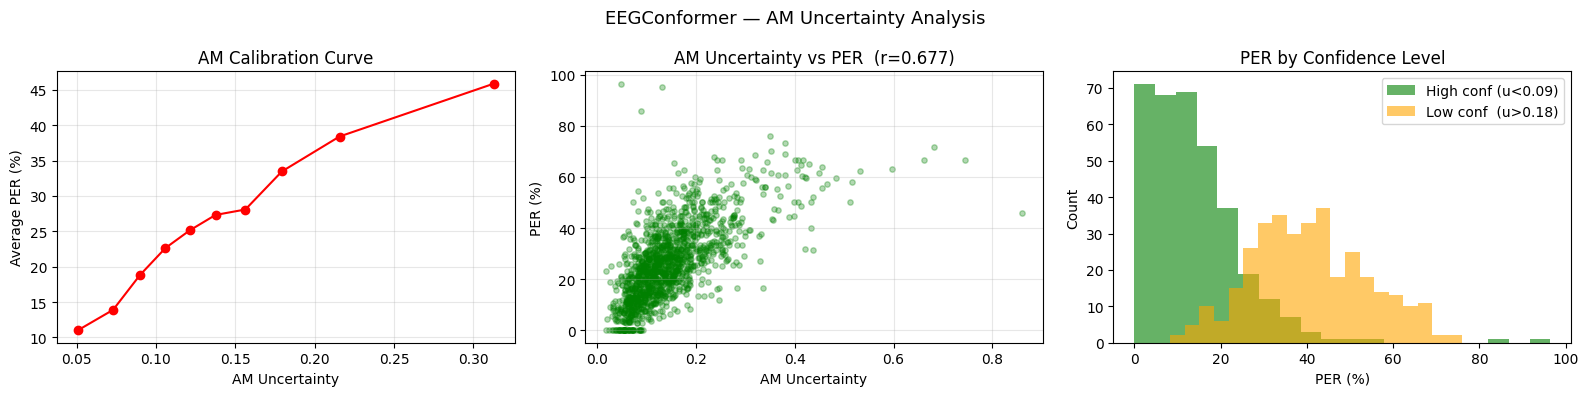

In [18]:
# ================================================================
# EEGConformer AM Uncertainty Analysis
# Prerequisites: model_eval is loaded and set to eval mode, val_loader is built.
# ================================================================
# ── 1. AM sequence score (uncertainty) ───────────────────────────
def compute_am_sequence_score(log_probs, input_lengths):
    """
    Per-sample AM uncertainty = negative mean of max log-prob
    over valid CTC timesteps. Higher value → less confident.

    log_probs     : (T, B, C)
    input_lengths : (B,)
    Returns       : Tensor (B,)
    """
    max_log_probs = log_probs.max(dim=-1)[0]  # (T, B)
    scores = []
    for i in range(log_probs.shape[1]):
        valid_len = int(input_lengths[i].item())
        score = max_log_probs[:valid_len, i].mean().item()
        scores.append(-score)
    return torch.tensor(scores)


# ── 2. MC-Dropout uncertainty (optional, slower) ─────────────────
def mc_dropout_uncertainty(model, neural_batch, input_lengths, n_samples=20):
    """
    Forces Dropout active and runs n_samples stochastic forward passes.
    Returns mean_probs (T,B,C) and predictive entropy per sample (B,).
    """
    model.train()  # keep Dropout on
    probs_list = []
    with torch.no_grad():
        for _ in range(n_samples):
            log_probs, _ = model(neural_batch, input_lengths)
            probs_list.append(log_probs.exp())
    model.eval()

    probs_stack = torch.stack(probs_list, dim=0)   # (N, T, B, C)
    mean_probs  = probs_stack.mean(dim=0)           # (T, B, C)

    # Predictive entropy H = -sum p*log(p)
    entropy = -(mean_probs * (mean_probs + 1e-8).log()).sum(dim=-1)  # (T, B)

    uncertainty = []
    for i in range(mean_probs.shape[1]):
        valid_len = int(input_lengths[i].item())
        uncertainty.append(entropy[:valid_len, i].mean().item())

    return mean_probs, torch.tensor(uncertainty)


# ── 3. Full evaluation loop ───────────────────────────────────────
def evaluate_am_uncertainty(model, val_loader, device, eval_config,
                             use_mc_dropout=False, n_mc_samples=20):
    """
    Runs the full val set and collects:
      - per-sample PER
      - per-sample AM uncertainty (sequence score or MC-Dropout entropy)
    """
    model.eval()
    k_w = eval_config['pool_kernel'][1]
    s_w = eval_config['pool_stride'][1]

    all_pers          = []
    all_am_uncs       = []
    all_mc_uncs       = []   # only populated if use_mc_dropout=True
    samples           = []

    with torch.no_grad():
        for batch_feat, batch_ids, batch_lens, input_time_steps in tqdm(val_loader, desc='AM Uncertainty'):
            batch_feat    = batch_feat.to(device)
            input_lengths = compute_token_lengths(input_time_steps, k_w, s_w).to(device)

            with torch.autocast(device_type=device.type, dtype=torch.float16):
                log_probs, _ = model(batch_feat, input_lengths)

            log_probs = log_probs.float()

            # Sequence-score uncertainty
            am_unc = compute_am_sequence_score(log_probs, input_lengths)

            # MC-Dropout (optional)
            if use_mc_dropout:
                _, mc_unc = mc_dropout_uncertainty(
                    model, batch_feat, input_lengths, n_samples=n_mc_samples)
                all_mc_uncs.extend(mc_unc.tolist())

            # Greedy decode + PER
            hyps = greedy_decode(log_probs)
            for i in range(len(hyps)):
                slen = int(batch_lens[i].item())
                ref  = batch_ids[i, :slen].tolist()
                hyp  = hyps[i]
                per  = levenshtein(ref, hyp) / max(len(ref), 1) * 100

                all_pers.append(per)
                all_am_uncs.append(am_unc[i].item())

                if len(samples) < 15:
                    samples.append({
                        'am_unc': am_unc[i].item(),
                        'per': per,
                        'ref': ref[:6],
                        'hyp': hyp[:6],
                    })

    # ── Print sample table ────────────────────────────────────────
    print(f"\n{'AM_UNC':<10} | {'PER':<8} | {'Reference (first 6)':<35} | Hypothesis (first 6)")
    print('-' * 95)
    for s in samples:
        ref_str = ' '.join(LOGIT_TO_PHONEME[p] for p in s['ref'])
        hyp_str = ' '.join(LOGIT_TO_PHONEME[p] for p in s['hyp'])
        print(f"{s['am_unc']:.4f}    | {s['per']:6.2f}% | {ref_str:<35} | {hyp_str}")

    # ── Correlation ───────────────────────────────────────────────
    corr = np.corrcoef(all_am_uncs, all_pers)[0, 1]
    print(f'\nAM Uncertainty vs PER correlation: {corr:.3f}')
    print(f'Mean PER : {np.mean(all_pers):.2f}%')
    print(f'Mean AM uncertainty : {np.mean(all_am_uncs):.4f}')

    # ── Confidence stratification ─────────────────────────────────
    q25, q50, q75 = np.percentile(all_am_uncs, [25, 50, 75])
    print(f'\n--- AM Confidence Stratification (quartiles: {q25:.3f} / {q50:.3f} / {q75:.3f}) ---')
    for lo, hi, label in [(0, q25, 'HIGH    '), (q25, q50, 'MEDIUM  '),
                          (q50, q75, 'LOW     '), (q75, 9999, 'VERY_LOW')]:
        grp = [p for p, u in zip(all_pers, all_am_uncs) if lo <= u < hi]
        if grp:
            print(f'{label}: {len(grp):4d} samples ({len(grp)/len(all_pers):.1%}),  '
                  f'mean PER={np.mean(grp):.2f}%,  median PER={np.median(grp):.2f}%')

    # ── Plots ─────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle('EEGConformer — AM Uncertainty Analysis', fontsize=13)

    # Calibration curve
    sorted_idx = np.argsort(all_am_uncs)
    s_pers = [all_pers[i] for i in sorted_idx]
    s_uncs = [all_am_uncs[i] for i in sorted_idx]
    n_bins = 10
    bin_size = max(len(s_pers) // n_bins, 1)
    bin_pers = [np.mean(s_pers[i*bin_size:(i+1)*bin_size]) for i in range(n_bins)]
    bin_uncs = [np.mean(s_uncs[i*bin_size:(i+1)*bin_size]) for i in range(n_bins)]
    axes[0].plot(bin_uncs, bin_pers, 'o-', color='red')
    axes[0].set_xlabel('AM Uncertainty'); axes[0].set_ylabel('Average PER (%)')
    axes[0].set_title('AM Calibration Curve'); axes[0].grid(True, alpha=0.3)

    # Scatter
    axes[1].scatter(all_am_uncs, all_pers, alpha=0.3, s=15, color='green')
    axes[1].set_xlabel('AM Uncertainty'); axes[1].set_ylabel('PER (%)')
    axes[1].set_title(f'AM Uncertainty vs PER  (r={corr:.3f})')
    axes[1].grid(True, alpha=0.3)

    # PER distribution split by confidence
    high_pers = [p for p, u in zip(all_pers, all_am_uncs) if u < q25]
    low_pers  = [p for p, u in zip(all_pers, all_am_uncs) if u >= q75]
    axes[2].hist(high_pers, bins=20, alpha=0.6, color='green',  label=f'High conf (u<{q25:.2f})')
    axes[2].hist(low_pers,  bins=20, alpha=0.6, color='orange', label=f'Low conf  (u>{q75:.2f})')
    axes[2].set_xlabel('PER (%)'); axes[2].set_ylabel('Count')
    axes[2].set_title('PER by Confidence Level'); axes[2].legend()

    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/EEGConformer_AM_uncertainty.png', dpi=150)
    plt.show()

    if use_mc_dropout and all_mc_uncs:
        corr_mc = np.corrcoef(all_mc_uncs, all_pers)[0, 1]
        print(f'\nMC-Dropout Uncertainty vs PER correlation: {corr_mc:.3f}')
        plt.figure(figsize=(6, 4))
        plt.scatter(all_mc_uncs, all_pers, alpha=0.3, s=15, color='purple')
        plt.xlabel('MC-Dropout Uncertainty'); plt.ylabel('PER (%)')
        plt.title(f'MC-Dropout Uncertainty vs PER  (r={corr_mc:.3f})')
        plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

    return all_pers, all_am_uncs


# ── 4. Run ────────────────────────────────────────────────────────
all_pers, all_am_uncs = evaluate_am_uncertainty(
    model_eval, val_loader, device, eval_config,
    use_mc_dropout=False,   # set True to also run MC-Dropout (slower)
    n_mc_samples=20,
)